In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [6]:
#################
##난수 발생#######

# 0 이상 1 미만의 균일 분포에서 무작위로 추출한 실수 10개를 1차원 배열(array) 형태로 반환한다.
data = np.random.rand(10)
print(data)

print()
# 가우시안 정규분포를 의미한다. 수학자 카를 프리드리히 가우스의 이름에서 우래
# 가우시안 표준 정규분포(평균 : 0, 표준편차 : 1)
data = np.random.randn(10)
print(data)

print()
# 균일 분포의 정수 난수
data = np.random.randint(10)
print(data)

[0.65459436 0.02337358 0.84060418 0.55826066 0.82616443 0.38995014
 0.57441111 0.07524986 0.59349809 0.32649581]

[-0.14422935 -1.55217177 -1.61560299 -0.45969114 -0.3809244  -0.39976871
 -0.29973043  0.55589186  2.4464044  -0.36054986]

0


In [9]:
##################################
#########데이터 순서 바꾸기#########
print('np.random.shuffle')
# np.random.shuffle : 배열의 요소 변경
data = np.arange(10)        # start, stop, step arrange(stop), arrange(start, stop), arrange(start, stop, step)
print(data)

# 배열의 요소를 섞어서 다시 배열에 저장
item = np.random.shuffle(data)
print(item)     # shuffle은 리턴값이 없으므로 None을 리턴한다.
print(data)


print('np.random.permutation')
data = np.arange(10)
print(data)
# np.random.permutation()은 배열의 요소를 그대로 유지한다.
# 즉, data의 배열은 변경되지 않는다.
item = np.random.permutation(data)
print(item)
print(data)

np.random.shuffle
[0 1 2 3 4 5 6 7 8 9]
None
[5 7 1 4 9 8 2 6 0 3]
np.random.permutation
[0 1 2 3 4 5 6 7 8 9]
[2 8 6 9 3 0 5 1 4 7]
[0 1 2 3 4 5 6 7 8 9]


In [10]:
###########################
#### 데이터 샘플링   #########
# np.random.choice(a, size=None, replace=True, p=Npne)
# a : 베열이면 배열 자체, 정수이면 arange(a) 명령으로 배열 생성
# size : 정수, 샘플 숫자
# replace : boolean. True이면 복원추출, False면 비복원추출
# p : 배열,각 데이터가 선택될 수 있는 확률


# 0~4 까지 배열 중, 5개 추출, 비복원 추출
print(np.random.choice(5, 5, replace=False))

data = np.arange(10)
print(np.random.choice(data, 5))        # default : replace=True

[4 0 3 1 2]
[6 1 5 7 0]


#### 추세선(Trend Line)
- 추세선(Trend Line)은 데이터의 추세를 그래픽으로 표시하고 예측 문제를 분석하는데 사용된다.
- 이러한 분석을 회귀분석(예측을 위해 사용하는 통계분석의 한가지)이라고 하며,
회귀분석을 사용하여 실제 데이터가 존재하지 않는 범위의 값을 예측할 수 있다.
- 추세선을 사용할 수 있는 차트 : 누적형이 아닌 2차원 영역형, 가로 막대형, 세로 막대형, 꺾은선형, 주식형,분산형, 거품형
- 추세선을 사용할 수 없는 차트 : 3차원, 누적형, 방사형, 원형, 표면형, 도넛형

In [17]:
X = 2 * np.random.rand(100, 1)
print(X.shape)
# print(X)

(100, 1)


(100, 1)
(100, 1)
(100, 2)
          X          y
0  0.126265   6.960148
1  0.144950   6.731542
2  0.261273   7.986367
3  0.392691   7.604763
4  1.263244  11.777485


<Axes: xlabel='X', ylabel='y'>

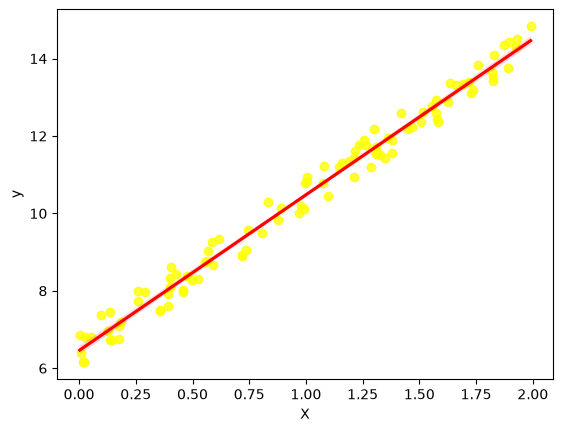

In [34]:
# y = 4X + 6

X = 2 * np.random.rand(100,1)           # 0~1미만 난수 발생 * 2
print(X.shape)
# print(X)

y = 6 + 4*X + np.random.rand(100,1)
print(y.shape)
# print(y)

# plt.scatter(X,y)

pd_X = pd.DataFrame(X, columns=['X'])
pd_y = pd.DataFrame(y, columns=['y'])
pd_df = pd.concat([pd_X, pd_y], axis = 1)
print(pd_df.shape)

print(pd_df.head())

sns.regplot(data=pd_df, x='X', y='y', line_kws={'color':'red'}, scatter_kws={'color':'yellow'})           # 추세선 그어짐

### 경사 하강법(gradient_descent_steps) _MSE(평균제곱오차계산식)
- 경사하강법(Gradient Descent)은 함수의 손실(오차)을 최소화하기 위해 기울기(Gradient)가 낮은 방향으로 매개변수를 반복해서 업데이트하는 최적화 알고리즘
- 파라미터 (Parameter) :  스스로 학습하며 최적의 값을 찾아가는 변수 -w, b

- 하이퍼파라미터 (Hyperparameter) : 모델이 학습을 시작하기 전에, 사람(개발자)이 외부에서 직접 설정해 주는 값 - learning_rate, l1, l2

추정된 w: 3.770 (실제 정답: 4)
추정된 b: 6.215 (실제 정답: 6)
Gradient Descent Total Cost: 0.8066


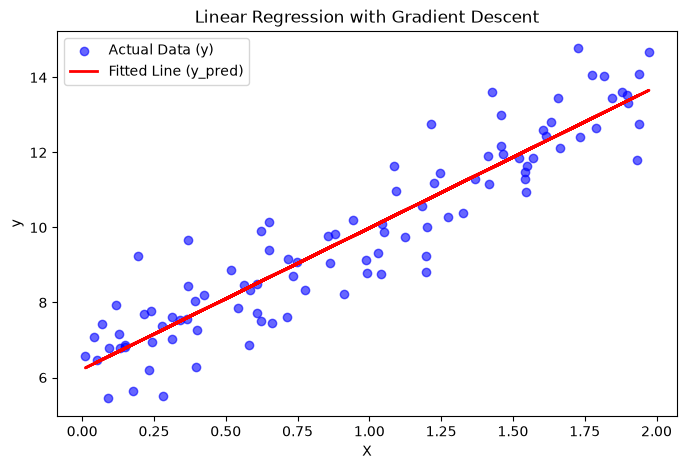

In [4]:
def get_weight_updates(w, b, X, y, learning_rate=0.01, l1=0.2, l2=0.7):
    N = len(y)  # 데이터 개수     
    
    # 1. 예측값 및 오차 계산
    y_pred = np.dot(X, w) + b   # 예측값: (N, 1)
    diff = y - y_pred             # 실제값 - 예측값: (N, 1)

    # 2. b_update를 dot행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
    b_factors = np.ones((N, 1))

    # 3. 기울기 방향 업데이트량 구하기 
    # (diff = y - y_pred 이므로 가중치를 오차 방향으로 '더해'주기 위한 + 값)
    w_update = (1 / N) * learning_rate * np.dot(X.T, diff)      #learning_rate는 안 줘도 되는데 보통 0.001 이정도로 준다..? 결과 보면서 조절 하면 되는 것
    b_update = (1 / N) * learning_rate * np.dot(b_factors.T, diff)
    
    return w_update, b_update

# 입력 인자 epochs로 주어진 횟수만큼 반복적으로 w와 b를 업데이트함
def gradient_descent_steps(X, y, epochs=1000, learning_rate=0.1):
    # w와 b를 모두 0으로 초기화
    w = np.zeros((1, 1))    
    b = np.zeros((1, 1))   # y = wX + b 

    for ind in range(epochs):
        w_update, b_update = get_weight_updates(w, b, X, y, learning_rate=learning_rate)
        
        # [수정] 빼기(-)가 아닌 더하기(+)를 수행해야 오차가 줄어듭니다.
        w = w + w_update
        b = b + b_update
        
    return w, b

# MSE(평균제곱오차) 계산 함수
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred)) / N
    return cost

# --------------------------------------------------
# 데이터 생성 및 실행
# --------------------------------------------------
np.random.seed(42)  # 재현성을 위한 난수 고정
X = 2 * np.random.rand(100, 1)
y = 6 + 4 * X + np.random.randn(100, 1)   # 실제 타깃: w=4, b=6

# 에포크를 1000으로 설정하여 충분히 수렴시킴
w, b = gradient_descent_steps(X, y, epochs=1000, learning_rate=0.05)        #1000번 훈련해라

print(f'추정된 w: {w[0, 0]:.3f} (실제 정답: 4)')
print(f'추정된 b: {b[0, 0]:.3f} (실제 정답: 6)')

y_pred = w[0, 0] * X + b
print(f'Gradient Descent Total Cost: {get_cost(y, y_pred):.4f}')

# 시각화
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Actual Data (y)', color='blue', alpha=0.6)
plt.plot(X, y_pred, label='Fitted Line (y_pred)', color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with Gradient Descent')
plt.legend()
plt.show()